In [ ]:
CLIENT_SECRET = 'WKLvBXft-wJ1oO3HgpFVv7ukqVFNRA'
CLIENT_ID = '1OaqVhfU1fU00wl8WQnIMA'

In [ ]:
! pip install PRAW

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 4.4 MB/s eta 0:00:00


In [ ]:
import praw
import pandas as pd
from datetime import datetime
import pytz

reddit = praw.Reddit(
    client_id= CLIENT_ID,
    client_secret= CLIENT_SECRET,
    user_agent='miami_merch_analysis'
)

start_date = datetime(2025, 5, 1, tzinfo=pytz.UTC)
end_date = datetime(2025, 5, 4, 23, 59, 59, tzinfo=pytz.UTC)

keywords = ['miami merch', 'miami gp', 'miami grand prix', 'f1 store', 'team kit', 'merch', 'merchandise','livery']

matched_comments = []

subreddit = reddit.subreddit('formula1')
for submission in subreddit.new(limit=1000):
    post_time = datetime.fromtimestamp(submission.created_utc, tz=pytz.UTC)
    if start_date <= post_time <= end_date:
        submission.comments.replace_more(limit=0)
        for comment in submission.comments.list():
            if comment.body:
                lower_comment = comment.body.lower()
                if any(kw in lower_comment for kw in keywords):
                    matched_comments.append({
                        'post_title': submission.title,
                        'comment_text': comment.body,
                        'author': str(comment.author),
                        'date': datetime.fromtimestamp(comment.created_utc).strftime('%Y-%m-%d %H:%M:%S')
                    })
df = pd.DataFrame(matched_comments)
df.to_csv('miami_gp_merch_comments.csv', index=False)
print(f"Collected {len(df)} relevant comments and saved to 'miami_gp_merch_comments.csv'")


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

🎉 Collected 310 relevant comments and saved to 'miami_gp_merch_comments.csv'


In [ ]:
merch_df = pd.read_csv('/content/miami_gp_merch_comments.csv')

In [ ]:
merch_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   post_title    310 non-null    object
 1   comment_text  310 non-null    object
 2   author        310 non-null    object
 3   date          310 non-null    object
dtypes: object(4)
memory usage: 9.8+ KB


In [ ]:
merch_df['comment_text'].dropna(inplace = True)

In [ ]:
merch_df.drop_duplicates(subset = ['post_title', 'comment_text'],inplace = True)

In [ ]:
merch_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 309 entries, 0 to 309
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   post_title    309 non-null    object
 1   comment_text  309 non-null    object
 2   author        309 non-null    object
 3   date          309 non-null    object
dtypes: object(4)
memory usage: 12.1+ KB


In [ ]:
merch_df['comment_text'] = merch_df['comment_text'].str.strip().str.lower()

In [ ]:
merch_df

,post_title,comment_text,author,date
0,They're already racing in Miami,"ok, i'm not much of a fan of miami gp as a who...",Aratho,2025-05-04 18:14:21
1,Current track conditions,"and it's always some surprising shit like ""lan...",razareddit,2025-05-04 18:13:50
2,The United States has now hosted more F1 races...,i'm american and i fucking hate the miami gp. ...,hoxxxxx,2025-05-04 17:56:26
3,The United States has now hosted more F1 races...,"massive market for sponsors, viewership, merch...",Trilly_Ray_Cyrus,2025-05-04 16:59:09
4,2025 Miami GP - Pre Race Discussion,i’ve realized cadillac did actually show off t...,ThingsFallApart_,2025-05-04 15:41:49
...,...,...,...,...
305,Ferrari Miami Grand Prix 2025 Poster,more embarassing than the double dnf imo\n\nun...,ihatemondaynights,2025-05-01 05:31:27
306,Ferrari Miami Grand Prix 2025 Poster,"livery, because you might have to see that thi...",flash_fk,2025-05-01 05:01:39
307,Ferrari Miami Grand Prix 2025 Poster,"yup, i don’t understand why people blame hp fo...",DubiousLLM,2025-05-01 02:59:20
308,[Alex Albon via IG] Freshly picked for the 305...,nice. \n\nwould go well with a gulf livery wil...,Popular_Composer_822,2025-05-01 07:22:51


In [ ]:
import re

# Function to clean text
def clean_text(text):
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)

    text = text.encode('ascii', 'ignore').decode('ascii')

    text = re.sub(r'[^a-zA-Z0-9\s.,!?\'\"]', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['cleaned_comment'] = df['comment_text'].apply(clean_text)

df.to_csv('cleaned_miami_gp_merch_comments.csv', index=False)

print("Comments cleaned and saved.")


✅ Comments cleaned and saved.


In [ ]:
cleaned_df = pd.read_csv('/content/cleaned_miami_gp_merch_comments.csv')

In [ ]:
cleaned_df

,post_title,comment_text,author,date,cleaned_comment
0,They're already racing in Miami,"Ok, I'm not much of a fan of Miami GP as a who...",Aratho,2025-05-04 18:14:21,"Ok, I'm not much of a fan of Miami GP as a who..."
1,Current track conditions,"And it's always some surprising shit like ""Lan...",razareddit,2025-05-04 18:13:50,"And it's always some surprising shit like ""Lan..."
2,The United States has now hosted more F1 races...,i'm american and i fucking hate the miami gp. ...,hoxxxxx,2025-05-04 17:56:26,i'm american and i fucking hate the miami gp. ...
3,The United States has now hosted more F1 races...,"massive market for sponsors, viewership, merch...",Trilly_Ray_Cyrus,2025-05-04 16:59:09,"massive market for sponsors, viewership, merch..."
4,2025 Miami GP - Pre Race Discussion,I’ve realized Cadillac did actually show off t...,ThingsFallApart_,2025-05-04 15:41:49,Ive realized Cadillac did actually show off th...
...,...,...,...,...,...
305,Ferrari Miami Grand Prix 2025 Poster,More embarassing than the double dnf imo\n\nUn...,ihatemondaynights,2025-05-01 05:31:27,More embarassing than the double dnf imo Uniro...
306,Ferrari Miami Grand Prix 2025 Poster,"Livery, because you might have to see that thi...",flash_fk,2025-05-01 05:01:39,"Livery, because you might have to see that thi..."
307,Ferrari Miami Grand Prix 2025 Poster,"Yup, I don’t understand why people blame HP fo...",DubiousLLM,2025-05-01 02:59:20,"Yup, I dont understand why people blame HP for..."
308,[Alex Albon via IG] Freshly picked for the 305...,Nice. \n\nWould go well with a gulf livery Wil...,Popular_Composer_822,2025-05-01 07:22:51,Nice. Would go well with a gulf livery Williams.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


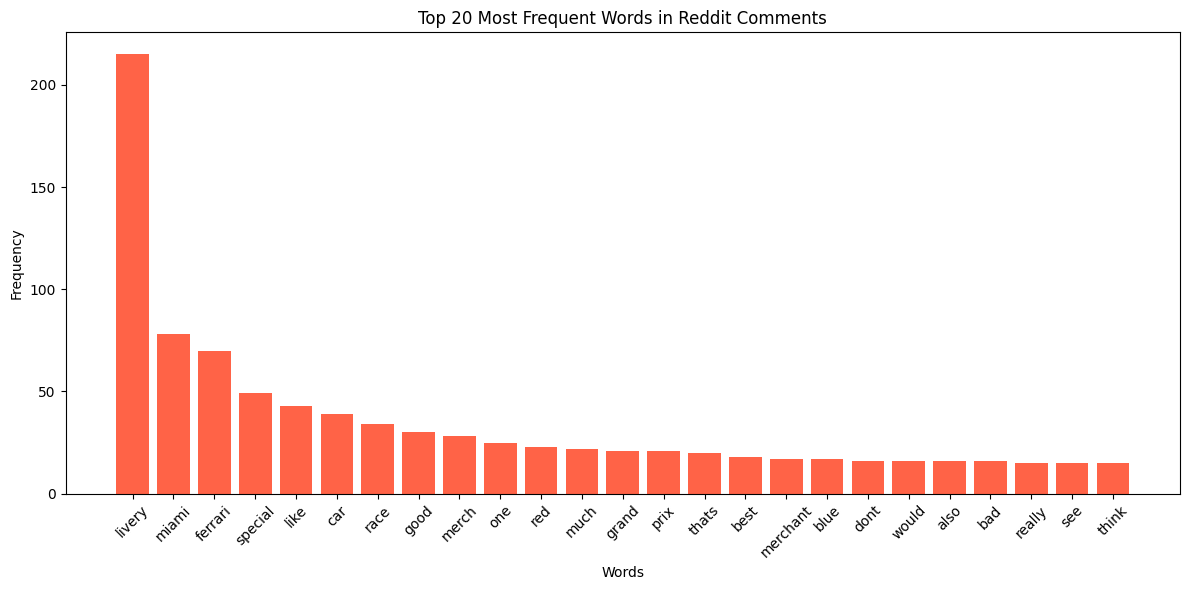

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
import string
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

text = " ".join(cleaned_df['cleaned_comment'].astype(str).tolist())

text = text.lower()
text = re.sub(r"http\S+", "", text)
text = re.sub(r"[^\w\s]", "", text)
text = re.sub(r"\d+", "", text)

tokens = text.split()
filtered_tokens = [word for word in tokens if word not in stop_words and len(word) > 2]

word_counts = Counter(filtered_tokens)
top_words = word_counts.most_common(25)

words_df = pd.DataFrame(top_words, columns=['word', 'count'])

plt.figure(figsize=(12, 6))
plt.bar(words_df['word'], words_df['count'], color='tomato')
plt.title("Top 20 Most Frequent Words in Reddit Comments")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


livery - 210
miami - 70
ferrari - 65
special - 48
like - 46
car - 45
race - 44
good - 43
merch - 42
one - 41
red - 40
one, red, much, grand, prix, thats - 35
best, merchant, blue, dont, would, also, bad, really, see, think - 25

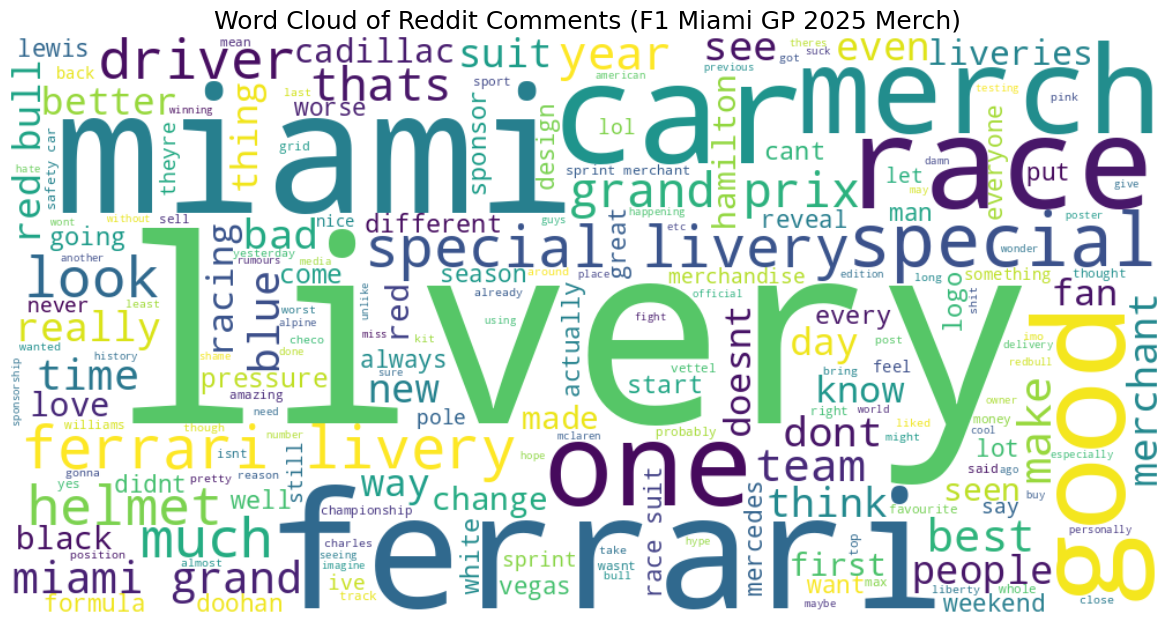

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text_for_cloud = " ".join(filtered_tokens)

wordcloud = WordCloud(width=1000, height=500, background_color='white', colormap='viridis').generate(text_for_cloud)

plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Reddit Comments (F1 Miami GP 2025 Merch)", fontsize=18)
plt.show()


In [ ]:
pip install nrclex


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


<Figure size 1000x600 with 0 Axes>

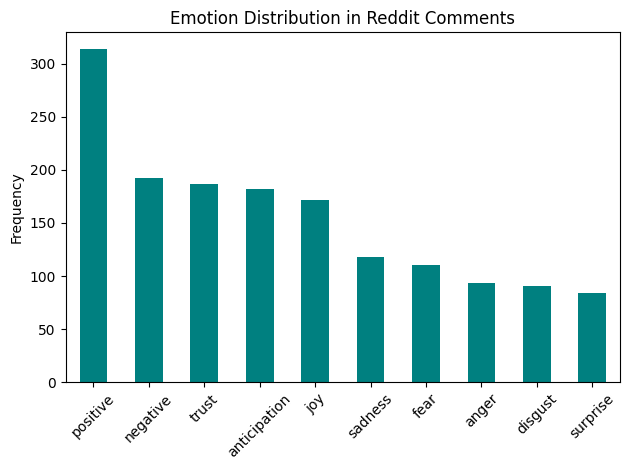

In [ ]:
from nrclex import NRCLex
from collections import Counter
import nltk
nltk.download('punkt_tab')

emotion_counts = Counter()

for comment in cleaned_df['cleaned_comment']:
    if isinstance(comment, str):
        emotion = NRCLex(comment)
        emotion_counts.update(emotion.raw_emotion_scores)

emotion_df = pd.DataFrame.from_dict(emotion_counts, orient='index', columns=['Count'])
emotion_df = emotion_df.sort_values(by='Count', ascending=False)

plt.figure(figsize=(10, 6))
emotion_df.plot(kind='bar', legend=False, color='teal')
plt.title("Emotion Distribution in Reddit Comments")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


positive - 310
negative - 190
trust - 170
anticipation - 166
joy - 155
sadness - 130
fear - 125
anger - 80

disgust - 70
surprise - 60